## 02-seq2seq: Experiment 노트북

### 목표
- LSTM 및 Attention으로 구성한 Seq-to-Seq 모델을 작은 batch에서 over-fitting
- Synthetic Reverse Task에서 학습 확인
- Attention을 이용한 Seq-to-seq에서 Attention Map 시각화
- 번역 태스크에서 Attention 유무에 따른 성능 비교

### 1. Import 및 설정

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
import math
import copy
import random
from typing import Tuple, Dict, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from model import Seq2Seq, AttentionSeq2Seq
from data import synthetic_reverse_dataset

In [3]:
def set_seed(seed: int = 42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.random.manual_seed(seed)

set_seed()

### 2. 작은 Batch에서 LSTM Seq2seq 모델 Overfitting 확인

In [4]:
batch_size = 16
min_seq, max_seq = 3, 6
embedding_size = 32
hidden_size = 64
vocab_size = 13

PAD_TOKEN = 0
BOS_TOKEN = 1
EOS_TOKEN = 2

source, target_input, target_output, valid_mask = \
    synthetic_reverse_dataset(batch_size=batch_size, min_seq=min_seq, max_seq=max_seq)

model = Seq2Seq(vocab_size=vocab_size, embedding_size=embedding_size, hidden_size=hidden_size)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN)
eval_mask = target_output != PAD_TOKEN

Step 0: loss=2.59, acc=0.05
Step 10: loss=0.96, acc=0.73
Step 20: loss=0.13, acc=1.00
Step 30: loss=0.02, acc=1.00
Step 40: loss=0.01, acc=1.00
Step 50: loss=0.00, acc=1.00
Step 60: loss=0.00, acc=1.00
Step 70: loss=0.00, acc=1.00
Step 80: loss=0.00, acc=1.00
Step 90: loss=0.00, acc=1.00


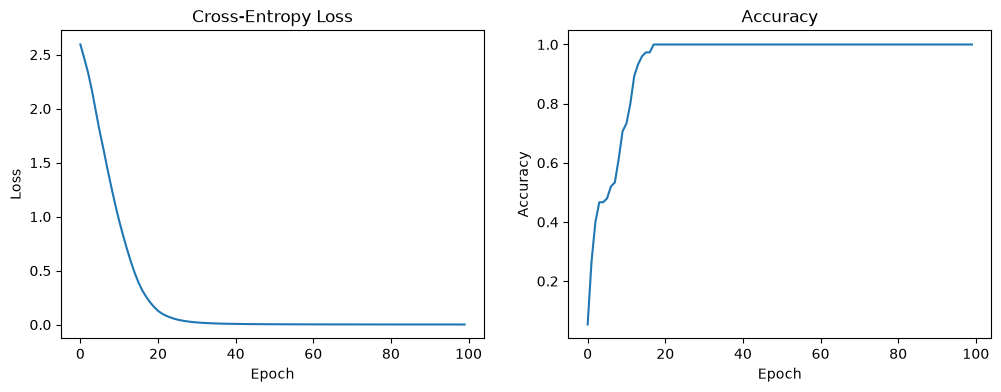

In [ ]:
loss_history, acc_history = [], []
model.train()
for i in range(100):
    optimizer.zero_grad()
    logits = model(source, target_input, valid_mask)
    loss = loss_fn(logits.reshape(-1, vocab_size), target_output.reshape(-1))
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    correct = (logits.argmax(dim=-1) == target_output) & eval_mask
    acc_history.append((torch.sum(correct) / torch.sum(eval_mask)).item())

    if i % 10 == 0:
        print(f"Step {i}: loss={loss.item():.2f}, acc={(torch.sum(correct) / torch.sum(eval_mask)):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(loss_history)
axes[0].set(title="Cross-Entropy Loss", xlabel="Epoch", ylabel='Loss')
axes[1].plot(acc_history)
axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
plt.show()

### 2-1. Greedy Decoding 및 Accuracy 평가 지표

In [6]:
# 학습한 모델을 이용해, Input Sequence에 대해 Decoder가 생성한 Token IDs 반환
model.eval()

with torch.no_grad():
    pred_ids = model.greedy_decode(
        source=source,
        valid_mask=valid_mask,
        max_new_tokens=target_output.shape[1]
    )

if pred_ids.shape[1] != target_output.shape[1]:
    pred_ids = F.pad(pred_ids, (0, target_output.shape[1]-pred_ids.shape[1]), value=PAD_TOKEN)

for pred, true in zip(pred_ids, target_output):
    print(f"Predicted: {pred}, True: {true}")

Predicted: tensor([ 9, 10,  5,  2,  0,  0,  0]), True: tensor([ 9, 10,  5,  2,  0,  0,  0])
Predicted: tensor([8, 9, 7, 2, 0, 0, 0]), True: tensor([8, 9, 7, 2, 0, 0, 0])
Predicted: tensor([11,  6,  3,  7,  3,  2,  0]), True: tensor([11,  6,  3,  7,  3,  2,  0])
Predicted: tensor([4, 7, 3, 7, 2, 0, 0]), True: tensor([4, 7, 3, 7, 2, 0, 0])
Predicted: tensor([10,  8,  8,  5,  2,  0,  0]), True: tensor([10,  8,  8,  5,  2,  0,  0])
Predicted: tensor([ 6,  9, 12,  9,  2,  0,  0]), True: tensor([ 6,  9, 12,  9,  2,  0,  0])
Predicted: tensor([ 6, 12,  4,  2,  0,  0,  0]), True: tensor([ 6, 12,  4,  2,  0,  0,  0])
Predicted: tensor([10, 12,  4,  2,  0,  0,  0]), True: tensor([10, 12,  4,  2,  0,  0,  0])
Predicted: tensor([ 6, 12,  8,  3,  5, 12,  2]), True: tensor([ 6, 12,  8,  3,  5, 12,  2])
Predicted: tensor([ 9, 12,  7,  2,  0,  0,  0]), True: tensor([ 9, 12,  7,  2,  0,  0,  0])
Predicted: tensor([9, 3, 5, 2, 0, 0, 0]), True: tensor([9, 3, 5, 2, 0, 0, 0])
Predicted: tensor([12, 10,  5,

In [ ]:
# 각 sequence 별 accuracy 확인
accuracy = (pred_ids == target_output)
accuracy = torch.all(accuracy, dim=1)
baseline_sequence_accuracy = accuracy.sum() / accuracy.size(0)
print("Accuracy:", baseline_sequence_accuracy.item())

Accuracy: 1.0


### 3. 작은 Batch에서 Attention Seq2seq 모델 Overfitting 확인

Step 0: loss=2.59, acc=0.05
Step 10: loss=0.76, acc=0.91
Step 20: loss=0.09, acc=1.00
Step 30: loss=0.01, acc=1.00
Step 40: loss=0.00, acc=1.00
Step 50: loss=0.00, acc=1.00
Step 60: loss=0.00, acc=1.00
Step 70: loss=0.00, acc=1.00
Step 80: loss=0.00, acc=1.00
Step 90: loss=0.00, acc=1.00


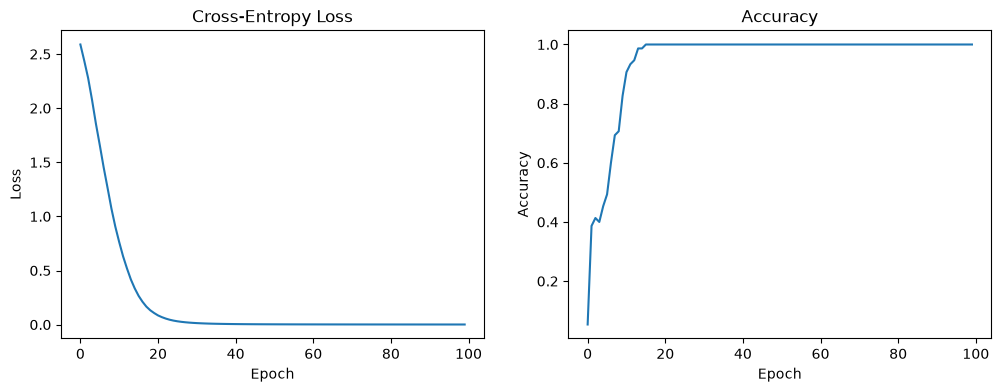

In [10]:
attention_model = AttentionSeq2Seq(vocab_size=vocab_size, embedding_size=embedding_size, hidden_size=hidden_size, attention_size=hidden_size)
attention_optimizer = torch.optim.Adam(attention_model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN)
eval_mask = target_output != PAD_TOKEN

attention_model.train()
attention_loss_history, attention_acc_history = [], []
for i in range(100):
    attention_optimizer.zero_grad()
    logits, attention_weights = attention_model(source, target_input, valid_mask)
    loss = loss_fn(logits.reshape(-1, vocab_size), target_output.reshape(-1))
    loss.backward()
    attention_optimizer.step()

    attention_loss_history.append(loss.item())
    correct = (logits.argmax(dim=-1) == target_output) & eval_mask
    attention_acc_history.append((torch.sum(correct) / torch.sum(eval_mask)).item())

    if i % 10 == 0:
        print(f"Step {i}: loss={loss.item():.2f}, acc={(torch.sum(correct) / torch.sum(eval_mask)):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(attention_loss_history)
axes[0].set(title="Cross-Entropy Loss", xlabel="Epoch", ylabel='Loss')
axes[1].plot(attention_acc_history)
axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
plt.show()

### 3-1. Greedy Decoding 및 Accuracy 평가 지표

In [ ]:
attention_model.eval()
with torch.no_grad():
    pred_ids, attention_weights = attention_model.greedy_decode(
        source=source,
        valid_mask=valid_mask,
        max_new_tokens=target_output.shape[1]
    )

if pred_ids.shape[1] != target_output.shape[1]:
    pred_ids = F.pad(pred_ids, (0, target_output.shape[1]-pred_ids.shape[1]), value=PAD_TOKEN)

for pred, true in zip(pred_ids, target_output):
    print(f"Predicted: {pred}, True: {true}")

accuracy = (pred_ids == target_output)
accuracy = torch.all(accuracy, dim=1)
attention_sequence_accuracy = accuracy.sum() / accuracy.size(0)
print("=" * 50)
print("Accuracy:", attention_sequence_accuracy.item())

Predicted: tensor([ 9, 10,  5,  2,  0,  0,  0]), True: tensor([ 9, 10,  5,  2,  0,  0,  0])
Predicted: tensor([8, 9, 7, 2, 0, 0, 0]), True: tensor([8, 9, 7, 2, 0, 0, 0])
Predicted: tensor([11,  6,  3,  7,  3,  2,  0]), True: tensor([11,  6,  3,  7,  3,  2,  0])
Predicted: tensor([4, 7, 3, 7, 2, 0, 0]), True: tensor([4, 7, 3, 7, 2, 0, 0])
Predicted: tensor([10,  8,  8,  5,  2,  0,  0]), True: tensor([10,  8,  8,  5,  2,  0,  0])
Predicted: tensor([ 6,  9, 12,  9,  2,  0,  0]), True: tensor([ 6,  9, 12,  9,  2,  0,  0])
Predicted: tensor([ 6, 12,  4,  2,  0,  0,  0]), True: tensor([ 6, 12,  4,  2,  0,  0,  0])
Predicted: tensor([10, 12,  4,  2,  0,  0,  0]), True: tensor([10, 12,  4,  2,  0,  0,  0])
Predicted: tensor([ 6, 12,  8,  3,  5, 12,  2]), True: tensor([ 6, 12,  8,  3,  5, 12,  2])
Predicted: tensor([ 9, 12,  7,  2,  0,  0,  0]), True: tensor([ 9, 12,  7,  2,  0,  0,  0])
Predicted: tensor([9, 3, 5, 2, 0, 0, 0]), True: tensor([9, 3, 5, 2, 0, 0, 0])
Predicted: tensor([12, 10,  5,